# 01 — Acquire and validate SPY data

This notebook owns the raw-data step. It downloads the Yahoo response, replaces
the previous SPY raw file only after a successful write, reloads it, and performs
schema and data-quality checks.

The plots here are **sanity checks**, not model exploration. Model-directed 
exploratory data analysis is postponed until after the chronological split 
in notebook 02.

In [12]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "pyproject.toml").exists():
    raise FileNotFoundError("Run this notebook from the project root or notebooks folder.")

# This fallback makes the src-layout package importable even before an editable install.
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
import matplotlib.pyplot as plt

from market_volatility.data import (
    fetch_yahoo_data,
    load_yahoo_data,
    validate_price_data,
)

from market_volatility.plotting import save_figure

SYMBOL = "SPY"
DOWNLOAD_FRESH_DATA = True

## Download or load

Set `DOWNLOAD_FRESH_DATA = False` when you want to reproduce the project from
the existing raw snapshot without contacting Yahoo.

In [14]:
if DOWNLOAD_FRESH_DATA:
    raw_prices, raw_path = fetch_yahoo_data(SYMBOL)
else:
    raw_prices = load_yahoo_data(SYMBOL)
    raw_path = next((PROJECT_ROOT / "data" / "raw").glob("yahoo_spy*daily*.csv"))

validate_price_data(raw_prices)

print(f"File: {raw_path}")
print(f"Rows: {len(raw_prices):,}")
print(f"Dates: {raw_prices.index.min().date()} through {raw_prices.index.max().date()}")
print(f"Duplicate dates: {raw_prices.index.duplicated().sum()}")
print(f"Missing values: {raw_prices.isna().sum().sum()}")
display(raw_prices.head())
display(raw_prices.tail())

File: /Users/tonyli/Desktop/hands-on-ml-experiment/data/raw/yahoo_spy_daily_2026-09-05.csv
Rows: 8,458
Dates: 1993-01-29 through 2026-09-04
Duplicate dates: 0
Missing values: 0


,Adj Close,Capital Gains,Close,Dividends,High,Low,Open,Stock Splits,Volume
Date,,,,,,,,,
1993-01-29,24.113253,0.0,43.93750,0.0,43.96875,43.75000,43.96875,0.0,1003200
1993-02-01,24.284771,0.0,44.25000,0.0,44.25000,43.96875,43.96875,0.0,480500
1993-02-02,24.336210,0.0,44.34375,0.0,44.37500,44.12500,44.21875,0.0,201300
1993-02-03,24.593466,0.0,44.81250,0.0,44.84375,44.37500,44.40625,0.0,529400
1993-02-04,24.696371,0.0,45.00000,0.0,45.09375,44.46875,44.96875,0.0,531500


,Adj Close,Capital Gains,Close,Dividends,High,Low,Open,Stock Splits,Volume
Date,,,,,,,,,
2026-08-31,767.049988,0.0,767.049988,0.0,768.000000,764.719971,767.330017,0.0,38810800
2026-09-01,761.780029,0.0,761.780029,0.0,764.669983,759.479980,762.010010,0.0,41126300
2026-09-02,765.159973,0.0,765.159973,0.0,766.429993,761.729980,762.450012,0.0,29566200
2026-09-03,773.169983,0.0,773.169983,0.0,774.030029,767.450012,767.900024,0.0,43531600
2026-09-04,770.190002,0.0,770.190002,0.0,772.869995,769.000000,772.010010,0.0,34015600


In [15]:
raw_prices.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 8458 entries, 1993-01-29 to 2026-09-04
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Adj Close      8458 non-null   float64
 1   Capital Gains  8458 non-null   float64
 2   Close          8458 non-null   float64
 3   Dividends      8458 non-null   float64
 4   High           8458 non-null   float64
 5   Low            8458 non-null   float64
 6   Open           8458 non-null   float64
 7   Stock Splits   8458 non-null   float64
 8   Volume         8458 non-null   int64  
dtypes: float64(8), int64(1)
memory usage: 660.8 KB


## Raw-data sanity plots

Adjusted close is appropriate for return calculations because it accounts for
distributions. The percentage high-low range is preferable to the dollar spread:
a $5 range means something different when SPY is $100 versus $700.

Saved: /Users/tonyli/Desktop/hands-on-ml-experiment/reports/figures/01_raw_data_sanity.png


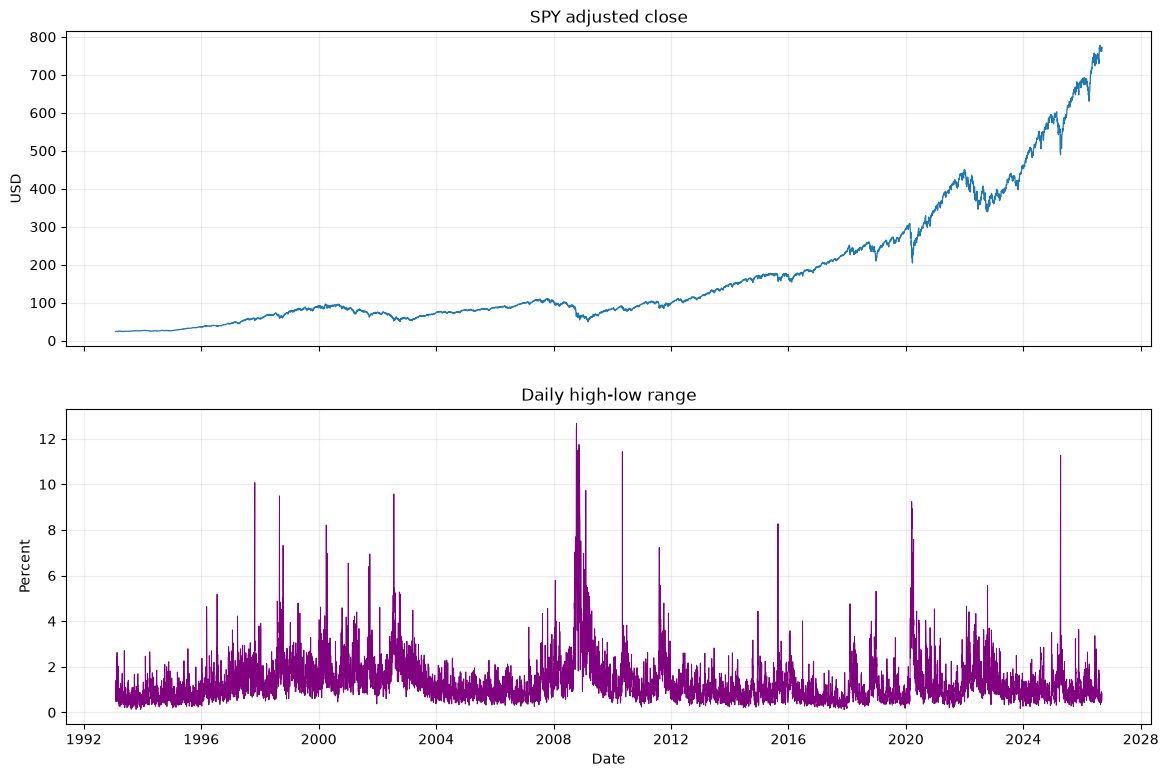

In [18]:
daily_range_pct = 100 * (raw_prices["High"] / raw_prices["Low"] - 1)

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex = True)

axes[0].plot(raw_prices.index, raw_prices["Adj Close"], linewidth = 0.9)
axes[0].set(title = "SPY adjusted close", ylabel = "USD")
axes[1].plot(raw_prices.index, daily_range_pct, linewidth = 0.7, color = "purple")
axes[1].set(title = "Daily high-low range", ylabel = "Percent", xlabel = "Date")

for axis in axes:
    axis.grid(alpha = 0.25)

path = save_figure(fig, "01_raw_data_sanity")
print(f"Saved: {path}")

plt.show()